In [1]:
import pandas as pd
import requests
import io
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [2]:
url = "https://www.rba.gov.au/statistics/tables/csv/g4-data.csv"
response = requests.get(url, verify=False)
df_cpi = pd.read_csv(io.StringIO(response.text), skiprows=11, names=['date', 'cpi_index', 'yoy_inflation', 'monthly_change_original', 'monthly_change_seasonally_adjusted'])
df_cpi.head(10)


,date,cpi_index,yoy_inflation,monthly_change_original,monthly_change_seasonally_adjusted
0,30/04/2024,96.40,NaN,NaN,NaN
1,31/05/2024,96.17,NaN,-0.2,0.3
2,30/06/2024,96.52,NaN,0.4,0.4
3,31/07/2024,96.77,NaN,0.3,-0.1
4,31/08/2024,96.49,NaN,-0.3,0.0
5,30/09/2024,96.54,NaN,0.1,-0.2
6,31/10/2024,96.32,NaN,-0.2,0.1
7,30/11/2024,96.68,NaN,0.4,0.6
8,31/12/2024,97.31,NaN,0.7,0.0
9,31/01/2025,97.58,NaN,0.3,0.5


In [3]:
print(df_cpi['date'].min())  
print(df_cpi['date'].max())
print(df_cpi.shape)

28/02/2025
31/12/2025
(27, 5)


In [4]:
df_cpi.tail(15)

,date,cpi_index,yoy_inflation,monthly_change_original,monthly_change_seasonally_adjusted
12,30/04/2025,98.68,2.4,0.7,0.2
13,31/05/2025,98.20,2.1,-0.5,0.0
14,30/06/2025,98.34,1.9,0.1,0.1
15,31/07/2025,99.63,3.0,1.3,0.9
16,31/08/2025,99.55,3.2,-0.1,0.2
17,30/09/2025,100.00,3.6,0.5,0.3
18,31/10/2025,99.99,3.8,0.0,0.4
19,30/11/2025,100.01,3.4,0.0,0.2
20,31/12/2025,100.97,3.8,1.0,0.2
21,31/01/2026,101.33,3.8,0.4,0.5


In [5]:
df_cpi.describe()

,cpi_index,yoy_inflation,monthly_change_original,monthly_change_seasonally_adjusted
count,24.000000,12.000000,23.000000,23.000000
mean,98.452500,3.275000,0.278261,0.282609
std,1.896159,0.797866,0.455229,0.300987
min,96.170000,1.900000,-0.500000,-0.200000
25%,96.645000,2.850000,0.000000,0.100000
50%,98.080000,3.500000,0.300000,0.200000
75%,99.992500,3.800000,0.450000,0.400000
max,102.440000,4.600000,1.300000,1.100000


In [6]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   date                                27 non-null     object 
 1   cpi_index                           24 non-null     float64
 2   yoy_inflation                       12 non-null     float64
 3   monthly_change_original             23 non-null     float64
 4   monthly_change_seasonally_adjusted  23 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.2+ KB


In [7]:
print(response.text[:1000])

G4 CONSUMER PRICE INFLATION – MONTHLY COLLECTION
Title,Consumer price index,Year-ended inflation,Monthly inflation – original,Monthly inflation
Description,Consumer price index; All groups,Consumer price index; All groups; Year-ended change (in per cent),Consumer price index; All groups; Original; Monthly change (in per cent),Consumer price index; All groups; Monthly change (in per cent)
Frequency,Monthly,Monthly,Monthly,Monthly
Type,Original,Original,Original,Seasonally adjusted
Units,"Index, September 2025 = 100",Per cent,Per cent,Per cent


Source,ABS,ABS,ABS,ABS
Publication date,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026
Series ID,GCPIAGM,GCPIAGYPM,GCPIAGMP,GCPIAGSAMP
30/04/2024,96.40
31/05/2024,96.17,,-0.2,0.3
30/06/2024,96.52,,0.4,0.4
31/07/2024,96.77,,0.3,-0.1
31/08/2024,96.49,,-0.3,0.0
30/09/2024,96.54,,0.1,-0.2
31/10/2024,96.32,,-0.2,0.1
30/11/2024,96.68,,0.4,0.6
31/12/2024,97.31,,0.7,0.0
31/01/2025,97.58,,0.3,0.5
28/02/2025,97.67,,0.1,0.3
31/03/2025,97.96,,0.3,0.3
30/04/

In [8]:
url_g1 = "https://www.rba.gov.au/statistics/tables/csv/g1-data.csv"  
response_g1 = requests.get(url_g1, verify=False)
print(response_g1.text[4000:5500])
df_cpi_g1 = pd.read_csv(io.StringIO(response_g1.text), skiprows=10, usecols=[0, 10, 20], header=None, names=['date', 'trimmed_mean_yoy', 'trimmed_mean_quarterly'])
df_cpi_g1 = df_cpi_g1.iloc[1:]
df_cpi_g1.head(10)

,Original,Original,Seasonally adjusted,Seasonally adjusted,Original,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted
Units,"Index, September 2025 month = 100",Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent


Source,ABS / RBA,ABS / RBA,ABS / RBA,RBA,RBA,RBA,RBA,RBA,ABS / RBA,ABS / RBA,ABS / RBA,ABS / RBA,ABS / RBA,RBA,RBA,RBA,RBA,RBA,ABS / RBA,ABS / RBA
Publication date,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026,30-Apr-2026
Series ID,GCPIAG,GCPIAGYP,GCPIEITCYP,GCPIXVIYP,GCPITIYP,GCPITXVIYP,GCPINTIYP,GCPINTXDLYP,GCPIOCPMWMYP,GCPIOCPMTMYP,GCPIAGQP,GCPIAGSAQ

,date,trimmed_mean_yoy,trimmed_mean_quarterly
1,30/06/1922,NaN,NaN
2,30/09/1922,NaN,NaN
3,31/12/1922,NaN,NaN
4,31/03/1923,NaN,NaN
5,30/06/1923,NaN,NaN
6,30/09/1923,NaN,NaN
7,31/12/1923,NaN,NaN
8,31/03/1924,NaN,NaN
9,30/06/1924,NaN,NaN
10,30/09/1924,NaN,NaN


In [9]:
df_cpi_g1.tail(10)

,date,trimmed_mean_yoy,trimmed_mean_quarterly
410,30/09/2024,3.6,0.8
411,31/12/2024,3.3,0.5
412,31/03/2025,2.9,0.7
413,30/06/2025,2.7,0.7
414,30/09/2025,3.0,1.0
415,31/12/2025,3.4,0.9
416,31/03/2026,3.5,0.8
417,30/06/2026,NaN,NaN
418,30/09/2026,NaN,NaN
419,31/12/2026,NaN,NaN


In [10]:
df_cpi_g1[df_cpi_g1['trimmed_mean_yoy'].notna()].head()

,date,trimmed_mean_yoy,trimmed_mean_quarterly
244,31/03/1983,10.7,2.2
245,30/06/1983,10.0,1.8
246,30/09/1983,8.5,1.5
247,31/12/1983,7.9,2.1
248,31/03/1984,7.0,1.4


In [11]:
df_cpi_g1.dtypes

date                      object
trimmed_mean_yoy          object
trimmed_mean_quarterly    object
dtype: object

In [12]:
url_h5 = "https://www.rba.gov.au/statistics/tables/csv/h5-data.csv"  
response_h5 = requests.get(url_h5, verify=False)
print(response_h5.text[:2000])
df_labour_force_h5 = pd.read_csv(io.StringIO(response_h5.text), skiprows=10, usecols=[0,10,11], names=['date','unemployed_%', 'unemployed_trend'])
df_labour_force_h5 = df_labour_force_h5.iloc[1:]
df_labour_force_h5.head(10)
df_labour_force_h5.tail(10)


H5 LABOUR FORCE
Title,Labour force,Participation rate,Part-time employment,Full-time employment,Employment,Year-ended employment growth,Year-ended employment trend growth,Employment to population ratio,Unemployment,Unemployment rate,Unemployment rate trend,Hours worked,Hours worked trend,Year-ended hours worked trend growth,Average hours worked trend,Job vacancies,Private sector job vacancies,Vacancies to labour force ratio
Description,Labour force persons,Labour force participation rate,Part-time employed persons,Full-time employed persons,Employed persons,Employed persons; Year-ended change (in per cent),Employed persons; Trend; Year-ended change (in per cent),Employed persons as percentage of working age civilian population,Unemployed persons,Unemployed persons as percentage of labour force,Unemployed persons as percentage of labour force; Trend,Total hours worked per month,Total hours worked per month; Trend,Total hours worked per month; Trend; Year-ended change (in per cent),Avera

,date,unemployed_%,unemployed_trend
572,30/09/2025,4.5,4.3
573,31/10/2025,4.3,4.3
574,30/11/2025,4.3,4.3
575,31/12/2025,4.1,4.3
576,31/01/2026,4.1,4.3
577,28/02/2026,4.3,4.3
578,31/03/2026,4.3,4.3
579,30/04/2026,NaN,NaN
580,31/05/2026,NaN,NaN
581,30/06/2026,NaN,NaN


In [13]:
url_i2 = "https://www.rba.gov.au/statistics/tables/csv/i2-data.csv"  
response_i2 = requests.get(url_i2, verify=False)
print(response_i2.text[:5000])
df_commodity_i2 = pd.read_csv(io.StringIO(response_i2.text), skiprows=10, usecols=[0,1,3,13,15], names=['date','overall_AU$', 'overall_US$', 'bulk_AU$','bulk_US$'])
df_commodity_i2 = df_commodity_i2.iloc[1:]
df_commodity_i2.head(10)
df_commodity_i2.tail(10)


I2 COMMODITY PRICES
Title,Commodity prices – A$,Commodity prices – SDR,Commodity prices – US$,Rural commodity prices – A$,Rural commodity prices – SDR,Rural commodity prices – US$,Non-rural commodity prices – A$,Non-rural commodity prices – SDR,Non-rural commodity prices – US$,Base metals prices – A$,Base metals prices – SDR,Base metals prices – US$,Bulk commodities prices – A$,Bulk commodities prices – SDR,Bulk commodities prices – US$,Commodity prices (with bulk commodities spot prices) – A$,Commodity prices (with bulk commodities spot prices) – SDR,Commodity prices (with bulk commodities spot prices) – US$,Bulk commodities spot prices – A$,Bulk commodities spot prices – SDR,Bulk commodities spot prices – US$
Description,Index of commodity prices; All items; A$,Index of commodity prices; All items; SDR,Index of commodity prices; All items; US$,Index of commodity prices; Rural component; A$,Index of commodity prices; Rural component; SDR,Index of commodity prices; Rural component; US$

,date,overall_AU$,overall_US$,bulk_AU$,bulk_US$
520,31/10/2025,102.0,103.1,97.1,98.2
521,30/11/2025,103.5,104.1,97.2,97.7
522,31/12/2025,102.8,105.5,96.1,98.7
523,31/01/2026,104.7,109.6,96.1,100.6
524,28/02/2026,102.0,111.2,92.1,100.3
525,31/03/2026,105.0,114.0,95.9,104.0
526,30/04/2026,104.2,113.8,95.6,104.4
527,31/05/2026,NaN,NaN,NaN,NaN
528,30/06/2026,NaN,NaN,NaN,NaN
529,31/07/2026,NaN,NaN,NaN,NaN


In [14]:
response_abs = requests.get("https://api.data.abs.gov.au/dataflow/ABS", verify=False)
print(response_abs.status_code)

import re
nom_matches = [m.start() for m in re.finditer('NOM', response_abs.text)]
for pos in nom_matches[:20]:
    print(response_abs.text[pos:pos+100])
    print('---')
          

200
NOM_VISA_CY" agencyID="ABS" version="1.0.0" isFinal="true">
        <common:Annotations>
          <
---
NOM_VISA_CY. Statistics on Australia's international immigration and emigration by state/territory a
---
NOM_VISA_CY" version="1.0.0" agencyID="ABS" package="datastructure" class="DataStructure" />
       
---
NOM_VISA_FY" agencyID="ABS" version="1.0.0" isFinal="true">
        <common:Annotations>
          <
---
NOM_VISA_FY. Statistics on Australia's international immigration and emigration by state/territory a
---
NOM_VISA_FY" version="1.0.0" agencyID="ABS" package="datastructure" class="DataStructure" />
       
---
NOM_CY" agencyID="ABS" version="1.0.0" isFinal="true">
        <common:Annotations>
          <commo
---
NOM_CY. Statistics on Australia's international immigration and emigration by state/territory, age a
---
NOM_CY" version="1.0.0" agencyID="ABS" package="datastructure" class="DataStructure" />
        </st
---
NOM_FY" agencyID="ABS" version="1.0.0" isFinal="tru

In [15]:
url_nom = "https://api.data.abs.gov.au/data/ABS,NOM_CY/all?format=jsondata&startPeriod=2000"
response_nom = requests.get(url_nom, verify=False)
print(response_nom.status_code)
print(response_nom.text[:2000])

200
{"meta":{"schema":"https://raw.githubusercontent.com/sdmx-twg/sdmx-json/master/data-message/tools/schemas/2.0.0/sdmx-json-data-schema.json","id":"IREF016672","prepared":"2026-05-18T23:38:35Z","test":true,"contentLanguages":["en"],"sender":{"id":"Stable_-_DotStat_v8","name":"unknown","names":{"en":"unknown"}}},"data":{"dataSets":[{"structure":0,"action":"Information","links":[{"urn":"urn:sdmx:org.sdmx.infomodel.datastructure.DataStructure=ABS:NOM_CY(1.0.0)","rel":"DataStructure"}],"annotations":[0,1,2,3,4,5],"series":{"0:0:0:0:0":{"attributes":[0],"annotations":[],"observations":{"0":[20570],"1":[23250],"2":[26860],"3":[31080],"4":[38970],"5":[32240],"6":[32970],"7":[37850],"8":[42640],"9":[34580],"10":[28150],"11":[26220],"12":[25280],"13":[22580],"14":[22360],"15":[28250],"16":[11680],"17":[8650],"18":[35540],"19":[47700],"20":[38760]}},"0:0:1:1:0":{"attributes":[0],"annotations":[],"observations":{"0":[168630],"1":[173450],"2":[190800],"3":[215020],"4":[253150],"5":[231190],"6":[

In [16]:
import json
nom_data = json.loads(response_nom.text)
print(list(nom_data.keys()))
print(list(nom_data['data'].keys()))

['meta', 'data', 'errors']
['dataSets', 'structures']


In [17]:
structure = nom_data['data']['structures'][0]
print(list(structure.keys()))

['name', 'names', 'description', 'descriptions', 'dimensions', 'attributes', 'annotations', 'dataSets']


In [18]:
for dim in structure['dimensions']['observation']:
    print(dim['id'], ':', dim['values'][:5])

TIME_PERIOD : [{'start': '2004-01-01T00:00:00', 'end': '2004-12-31T23:59:59', 'id': '2004', 'name': '2004', 'names': {'en': '2004'}}, {'start': '2005-01-01T00:00:00', 'end': '2005-12-31T23:59:59', 'id': '2005', 'name': '2005', 'names': {'en': '2005'}}, {'start': '2006-01-01T00:00:00', 'end': '2006-12-31T23:59:59', 'id': '2006', 'name': '2006', 'names': {'en': '2006'}}, {'start': '2007-01-01T00:00:00', 'end': '2007-12-31T23:59:59', 'id': '2007', 'name': '2007', 'names': {'en': '2007'}}, {'start': '2008-01-01T00:00:00', 'end': '2008-12-31T23:59:59', 'id': '2008', 'name': '2008', 'names': {'en': '2008'}}]


In [19]:
for dim in structure['dimensions']['series']:
    print(dim['id'], ':', [v['name'] for v in dim['values']])

MEASURE : ['NOM arrivals', 'NOM departures', 'Net Overseas Migration']
AGE : ['All ages', '45-49', '25-29', '55-59', '30-34', '50-54', '10-14', '15-19', '0-4', '40-44', '20-24', '5-9', '60-64', '65 and over', '35-39']
SEX : ['Males', 'Females', 'Persons']
REGION : ['Western Australia', 'Australia', 'South Australia', 'Australian Capital Territory', 'New South Wales', 'Tasmania', 'Queensland', 'Victoria', 'Northern Territory']
FREQ : ['Annual']


In [20]:
time_periods = [v['id'] for v in structure['dimensions']['observation'][0]['values']]
series = nom_data['data']['dataSets'][0]['series']['2:0:2:1:0']['observations']
nom_values = [series[str(i)][0] for i in range(len(time_periods))]

df_nom = pd.DataFrame({'year': time_periods, 'net_overseas_migration': nom_values})
print(df_nom)

    year  net_overseas_migration
0   2004                  138800
1   2005                  157180
2   2006                  197490
3   2007                  244030
4   2008                  315690
5   2009                  246900
6   2010                  172040
7   2011                  206240
8   2012                  240250
9   2013                  208380
10  2014                  182350
11  2015                  186730
12  2016                  243830
13  2017                  241660
14  2018                  252220
15  2019                  247620
16  2020                   -4970
17  2021                    9300
18  2022                  437860
19  2023                  530620
20  2024                  329940


In [21]:
url_h2 = "https://www.rba.gov.au/statistics/tables/csv/h2-data.csv"
response_h2 = requests.get(url_h2, verify=False)
print(response_h2.text[:500])
df_gov_exp_h2 = pd.read_csv(io.StringIO(response_h2.text), skiprows=10, usecols=[0,2,8], header=None, names=['date', 'household_consump', 'government_spending'])
df_gov_exp_h2 = df_gov_exp_h2.iloc[1:]
print(df_gov_exp_h2.head(10))
print(df_gov_exp_h2.tail(10))

H2 DEMAND AND INCOME
Title,Household consumption,Year-ended household consumption growth,Dwelling investment,Year-ended dwelling investment growth,Business investment,Year-ended business investment growth,Public demand,Year-ended public demand growth,Domestic final demand,Year-ended domestic final demand growth,Changes in inventories,Changes in inventories contribution to GDP year-ended growth,Gross national expenditure,Year-ended gross national expenditure growth,Household consumption share of 
          date household_consump government_spending
1   30/09/1959               NaN                 NaN
2   31/12/1959               NaN                 NaN
3   31/03/1960               NaN                 NaN
4   30/06/1960               NaN                 NaN
5   30/09/1960               6.4                 NaN
6   31/12/1960               2.7                 NaN
7   31/03/1961               0.4                 NaN
8   30/06/1961              -0.5                 NaN
9   30/09/1961        

In [22]:
url_h1 = "https://www.rba.gov.au/statistics/tables/csv/h1-data.csv"
response_h1 = requests.get(url_h1, verify=False)
print(response_h1.text[:500])
df_gdp_h1 = pd.read_csv(io.StringIO(response_h1.text), skiprows=10, usecols=[0,2,11], header=None, names=['date', 'GDP_%', 'ratio_exp_to_imp'])
df_gdp_h1 = df_gdp_h1.iloc[1:]
print(df_gdp_h1.head(10))
print(df_gdp_h1.tail(10))

H1 GROSS DOMESTIC PRODUCT AND INCOME
Title,Real GDP,Year-ended real GDP growth,Real non-farm GDP,Year-ended real non-farm GDP growth,Real farm GDP,Year-ended real GDP per capita growth,Real GDI,Year-ended real GDI growth,Nominal GDP,Year-ended nominal GDP growth,Terms of trade
Description,Gross domestic product (GDP); Chain volume,Gross domestic product (GDP); Chain volume; Year-ended change (in per cent),Gross domestic product (GDP); Non-farm; Chain volume,Gross domestic product (GDP); Non-farm
          date GDP_% ratio_exp_to_imp
1   30/09/1959   NaN             56.8
2   31/12/1959   NaN             55.8
3   31/03/1960   NaN             59.3
4   30/06/1960   NaN             59.8
5   30/09/1960   4.4             55.6
6   31/12/1960   3.3             58.4
7   31/03/1961   3.1             55.8
8   30/06/1961  -0.8             52.7
9   30/09/1961  -1.7             55.7
10  31/12/1961  -0.4             54.8
           date GDP_% ratio_exp_to_imp
260  30/06/2024   0.9             98.2
261

In [23]:
url_h4 = "https://www.rba.gov.au/statistics/tables/csv/h4-data.csv"
response_h4 = requests.get(url_h4, verify=False)
print(response_h4.text[:500])
df_productivity_h4 = pd.read_csv(io.StringIO(response_h4.text), skiprows=10, usecols=[0,1,9], header=None, names=['date', 'year_ended_wage_growth', 'year_ended_productivity_growth'])
df_productivity_h4 = df_productivity_h4.iloc[1:]
print(df_productivity_h4.head(10))
print(df_productivity_h4.tail(10))

H4 LABOUR COSTS AND PRODUCTIVITY
Title,Year-ended wage growth,Year-ended private sector wage growth,Year-ended public sector wage growth,Quarterly wage growth,Quarterly private sector wage growth,Quarterly public sector wage growth,Year-ended non-farm unit labour costs growth,Year-ended non-farm average earnings per hour growth,Year-ended non-farm labour productivity per hour growth,Non-farm labour productivity per hour
Description,Wage price index; Year-ended change (in per cent),Wage price ind
          date year_ended_wage_growth year_ended_productivity_growth
1   30/09/1985                    NaN                            NaN
2   31/12/1985                    NaN                            NaN
3   31/03/1986                    NaN                            NaN
4   30/06/1986                    NaN                            NaN
5   30/09/1986                    NaN                           -3.8
6   31/12/1986                    NaN                           -1.5
7   31/03/1987  

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

In [25]:
for df in [df_cpi_g1, df_labour_force_h5, df_commodity_i2, df_gov_exp_h2, df_productivity_h4, df_gdp_h1]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [26]:
for df in [df_cpi_g1, df_labour_force_h5, df_commodity_i2, df_gov_exp_h2, df_productivity_h4, df_gdp_h1]:
    print(df['date'].dtype, df['date'].min(), df['date'].max())

datetime64[ns] 1922-06-30 00:00:00 2026-12-31 00:00:00
datetime64[ns] 1978-02-28 00:00:00 2026-06-30 00:00:00
datetime64[ns] 1982-07-31 00:00:00 2026-07-31 00:00:00
datetime64[ns] 1959-09-30 00:00:00 2026-09-30 00:00:00
datetime64[ns] 1985-09-30 00:00:00 2026-12-31 00:00:00
datetime64[ns] 1959-09-30 00:00:00 2026-09-30 00:00:00


C:\Users\User\AppData\Local\Temp\ipykernel_6612\1299423759.py:32: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_plot['overll_AU$_yoy'] = df_plot['overall_AU$'].pct_change(12) * 100
C:\Users\User\AppData\Local\Temp\ipykernel_6612\1299423759.py:33: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_plot['bulk_AU$_yoy'] = df_plot['bulk_AU$'].pct_change(12) * 100


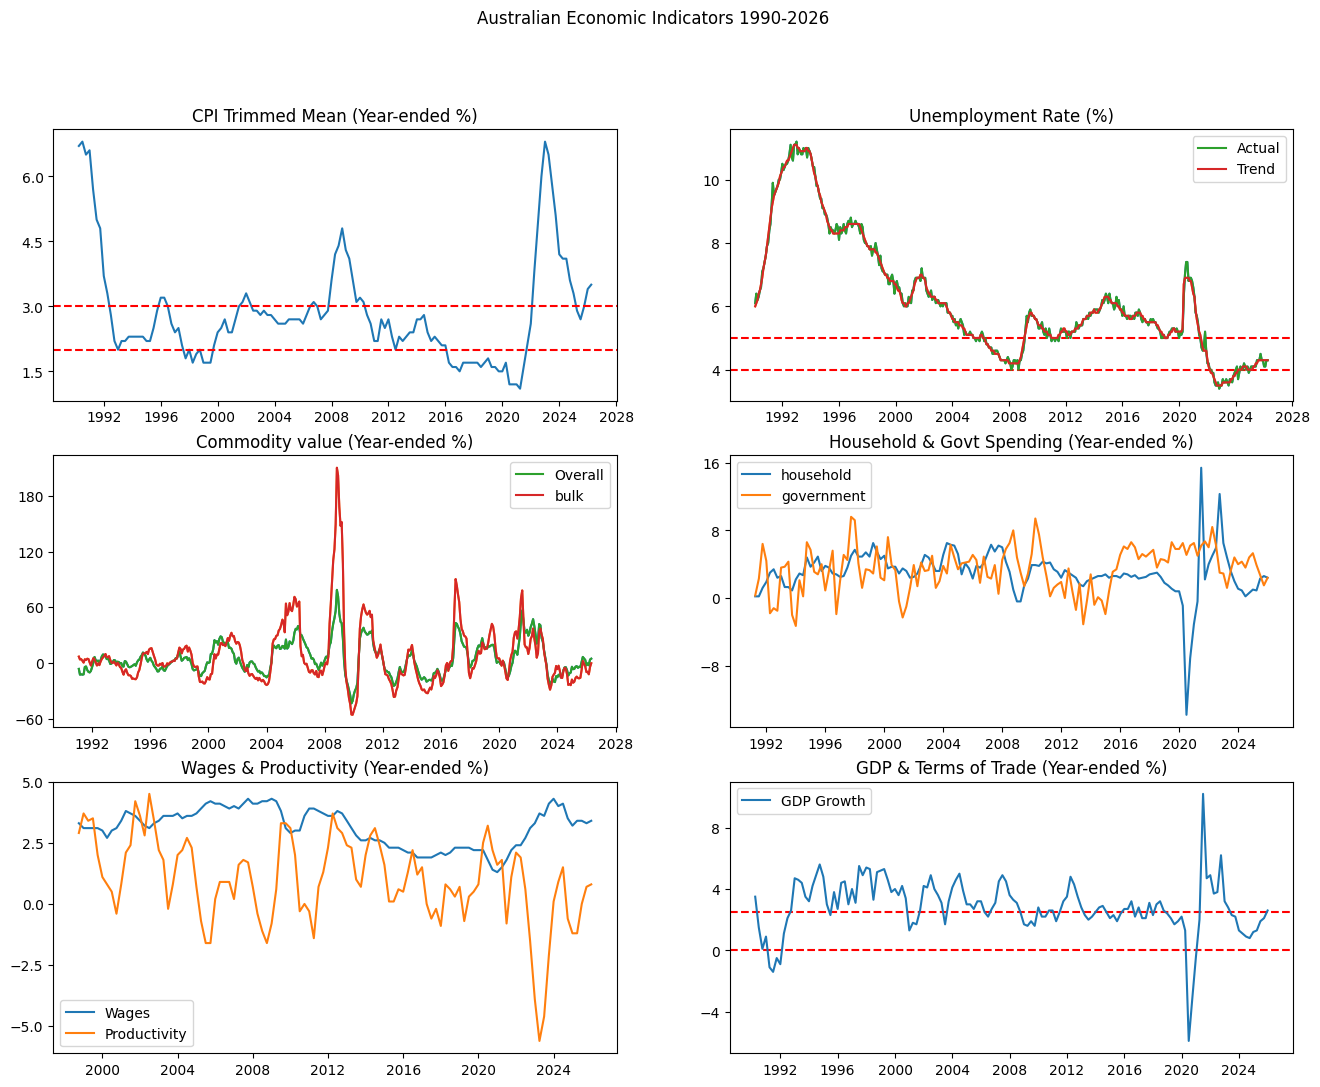

In [27]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16,12))
fig.suptitle('Australian Economic Indicators 1990-2026')

df_plot = df_cpi_g1[df_cpi_g1['date'] >= '1990-01-01'].copy()
df_plot['trimmed_mean_yoy'] = pd.to_numeric(df_plot['trimmed_mean_yoy'], errors='coerce')
df_plot = df_plot.dropna()
axes[0,0].yaxis.set_major_locator(plt.MaxNLocator(5))
axes[0,0].plot(df_plot['date'], df_plot['trimmed_mean_yoy'])
axes[0,0].set_title('CPI Trimmed Mean (Year-ended %)')
axes[0,0].axhline(y=2, color='r', linestyle='--')
axes[0,0].axhline(y=3, color='r', linestyle='--')


df_plot = df_labour_force_h5[df_labour_force_h5['date'] >= '1990-01-01'].copy()
df_plot['unemployed_%'] = pd.to_numeric(df_plot['unemployed_%'], errors='coerce')
df_plot['unemployed_trend'] = pd.to_numeric(df_plot['unemployed_trend'], errors='coerce')
df_plot = df_plot.dropna()
axes[0,1].yaxis.set_major_locator(plt.MaxNLocator(5))
axes[0,1].plot(df_plot['date'], df_plot['unemployed_%'])
axes[0,1].plot(df_plot['date'], df_plot['unemployed_trend'])
axes[0,1].set_title('Unemployment Rate (%)')
axes[0,1].axhline(y=4, color='r', linestyle='--')
axes[0,1].axhline(y=5, color='r', linestyle='--')
axes[0,1].plot(df_plot['date'], df_plot['unemployed_%'], label='Actual')
axes[0,1].plot(df_plot['date'], df_plot['unemployed_trend'], label='Trend')
axes[0,1].legend()


df_plot = df_commodity_i2[df_commodity_i2['date'] >= '1990-01-01'].copy()
df_plot['overall_AU$'] = pd.to_numeric(df_plot['overall_AU$'], errors='coerce')
df_plot['bulk_AU$'] = pd.to_numeric(df_plot['bulk_AU$'], errors='coerce')
df_plot['overll_AU$_yoy'] = df_plot['overall_AU$'].pct_change(12) * 100
df_plot['bulk_AU$_yoy'] = df_plot['bulk_AU$'].pct_change(12) * 100
df_plot = df_plot.dropna()
axes[1,0].yaxis.set_major_locator(plt.MaxNLocator(5))
axes[1,0].plot(df_plot['date'], df_plot['overll_AU$_yoy'])
axes[1,0].plot(df_plot['date'], df_plot['bulk_AU$_yoy'])
axes[1,0].set_title('Commodity value (Year-ended %)')
axes[1,0].plot(df_plot['date'], df_plot['overll_AU$_yoy'], label='Overall')
axes[1,0].plot(df_plot['date'], df_plot['bulk_AU$_yoy'], label='bulk')
axes[1,0].legend()


df_plot = df_gov_exp_h2[df_gov_exp_h2['date'] >= '1990-01-01'].copy()
df_plot['household_consump'] = pd.to_numeric(df_plot['household_consump'], errors='coerce')
df_plot['government_spending'] = pd.to_numeric(df_plot['government_spending'], errors='coerce')
df_plot = df_plot.dropna()
axes[1,1].yaxis.set_major_locator(plt.MaxNLocator(5))
axes[1,1].set_title('Household & Govt Spending (Year-ended %)')
axes[1,1].plot(df_plot['date'], df_plot['household_consump'], label='household')
axes[1,1].plot(df_plot['date'], df_plot['government_spending'], label='government')
axes[1,1].legend()

df_plot = df_productivity_h4[df_productivity_h4['date'] >= '1990-01-01'].copy()  
df_plot['year_ended_wage_growth'] = pd.to_numeric(df_plot['year_ended_wage_growth'], errors='coerce')
df_plot['year_ended_productivity_growth'] = pd.to_numeric(df_plot['year_ended_productivity_growth'], errors='coerce')  
df_plot = df_plot.dropna()
axes[2,0].yaxis.set_major_locator(plt.MaxNLocator(5))
axes[2,0].plot(df_plot['date'], df_plot['year_ended_wage_growth'], label='Wages')
axes[2,0].plot(df_plot['date'], df_plot['year_ended_productivity_growth'], label='Productivity')
axes[2,0].set_title('Wages & Productivity (Year-ended %)')
axes[2,0].legend()

df_plot = df_gdp_h1[df_gdp_h1['date'] >= '1990-01-01'].copy()
df_plot['GDP_%'] = pd.to_numeric(df_plot['GDP_%'], errors='coerce')
#df_plot['ratio_exp_to_imp'] = pd.to_numeric(df_plot['ratio_exp_to_imp'], errors='coerce')  
df_plot = df_plot.dropna()
axes[2,1].axhline(y=0, color='r', linestyle='--')
axes[2,1].axhline(y=2.5, color='r', linestyle='--')
axes[2,1].yaxis.set_major_locator(plt.MaxNLocator(5))  
axes[2,1].plot(df_plot['date'], df_plot['GDP_%'], label='GDP Growth')
#axes[2,1].plot(df_plot['date'], df_plot['ratio_exp_to_imp'], label='Terms of Trade')
axes[2,1].set_title('GDP & Terms of Trade (Year-ended %)')
axes[2,1].legend()


In [28]:
print(df_commodity_i2[df_commodity_i2['date'] >= '1990-01-01'].dropna()[['date','overall_AU$']].head(10))  
print(df_commodity_i2['overall_AU$'].dtype)

          date overall_AU$
91  1990-01-31        31.3
92  1990-02-28        31.7
93  1990-03-31        32.0
94  1990-04-30        31.8
95  1990-05-31        31.8
96  1990-06-30        30.1
97  1990-07-31        29.4
98  1990-08-31        29.9
99  1990-09-30        30.1
100 1990-10-31        30.4
object


In [48]:
from google.cloud import bigquery

client = bigquery.Client(project='rba-pipeline-494410')

delete_query = """
    DELETE FROM `rba-pipeline-494410.gold.rba_decisions`
    WHERE date = '99 May 2099'
"""
client.query(delete_query).result()
print("Deleted")
query = """
    SELECT *
    FROM `rba-pipeline-494410.gold.rba_decisions`
    ORDER BY date
"""

df_rba = client.query(query).to_dataframe()
df_rba['date'] = pd.to_datetime(df_rba['date'], format='%d %b %Y')
print(df_rba.shape)
print(df_rba['date'].min(), df_rba['date'].max())
                                 

Deleted


C:\Users\User\OneDrive\Documents\Data storage\python\scripts\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(399, 3)
1990-01-23 00:00:00 2026-05-06 00:00:00


In [38]:
df_rba.head(10)

,date,change,cash_rate
0,2025-10-01,0.00,3.60
1,2025-12-10,0.00,3.60
2,1996-12-11,-0.50,6.00
3,2024-12-11,0.00,4.35
4,2025-08-13,-0.25,3.60
5,1994-12-14,+1.00,7.50
6,1991-06-14,0.00,10.50
7,1990-02-15,-0.50,16.50 to 17.00
8,1990-10-15,-1.00,13.00
9,1991-05-16,-1.00,10.50


In [49]:
print(df_rba[df_rba['cash_rate'].astype(str).str.contains('to')].shape[0])

7


In [50]:
def parse_rate(val):
    val = str(val)
    if 'to' in val:
        low, high = val.split(' to ')
        return (float(low) + float(high)) / 2
    return float(val)

df_rba['change'] = pd.to_numeric(df_rba['change'].astype(str).str.replace('+', '', regex=False), errors='coerce')
df_rba['cash_rate'] = pd.to_numeric(df_rba['cash_rate'], errors='coerce')
df_rba = df_rba.sort_values('date').reset_index(drop=True)

print(df_rba.dtypes)
df_rba.head(10)

date         datetime64[ns]
change              float64
cash_rate           float64
dtype: object


,date,change,cash_rate
0,1990-01-23,NaN,NaN
1,1990-02-15,-0.5,NaN
2,1990-03-07,0.0,NaN
3,1990-04-04,NaN,NaN
4,1990-05-02,0.0,NaN
5,1990-06-06,0.0,NaN
6,1990-07-04,0.0,NaN
7,1990-08-02,-1.0,14.0
8,1990-09-05,0.0,14.0
9,1990-10-15,-1.0,13.0


In [51]:
print(df_rba.tail(5))
print(df_rba['cash_rate'].isna().sum())

          date  change  cash_rate
394 2025-11-05    0.00       3.60
395 2025-12-10    0.00       3.60
396 2026-02-04    0.25       3.85
397 2026-03-18    0.25       4.10
398 2026-05-06    0.25       4.35
7


In [54]:
rates = {
  '1990-01-23': (17.25, None),
  '1990-02-15': (16.75, -0.50),
  '1990-03-07': (16.75, 0.00),
  '1990-04-04': (15.25, -1.50),
  '1990-05-02': (15.25, 0.00),
  '1990-06-06': (15.25, 0.00),
  '1990-07-04': (15.25, 0.00),
}

for date_str, (rate, change) in rates.items():
    mask = df_rba['date'] == pd.Timestamp(date_str)
    df_rba.loc[mask, 'cash_rate'] = rate
    if change is not None:
        df_rba.loc[mask, 'change'] = change

print(df_rba.head(10))

        date  change  cash_rate
0 1990-01-23     NaN      17.25
1 1990-02-15    -0.5      16.75
2 1990-03-07     0.0      16.75
3 1990-04-04    -1.5      15.25
4 1990-05-02     0.0      15.25
5 1990-06-06     0.0      15.25
6 1990-07-04     0.0      15.25
7 1990-08-02    -1.0      14.00
8 1990-09-05     0.0      14.00
9 1990-10-15    -1.0      13.00


In [56]:
print(df_rba.isna().sum())

date         0
change       1
cash_rate    0
dtype: int64


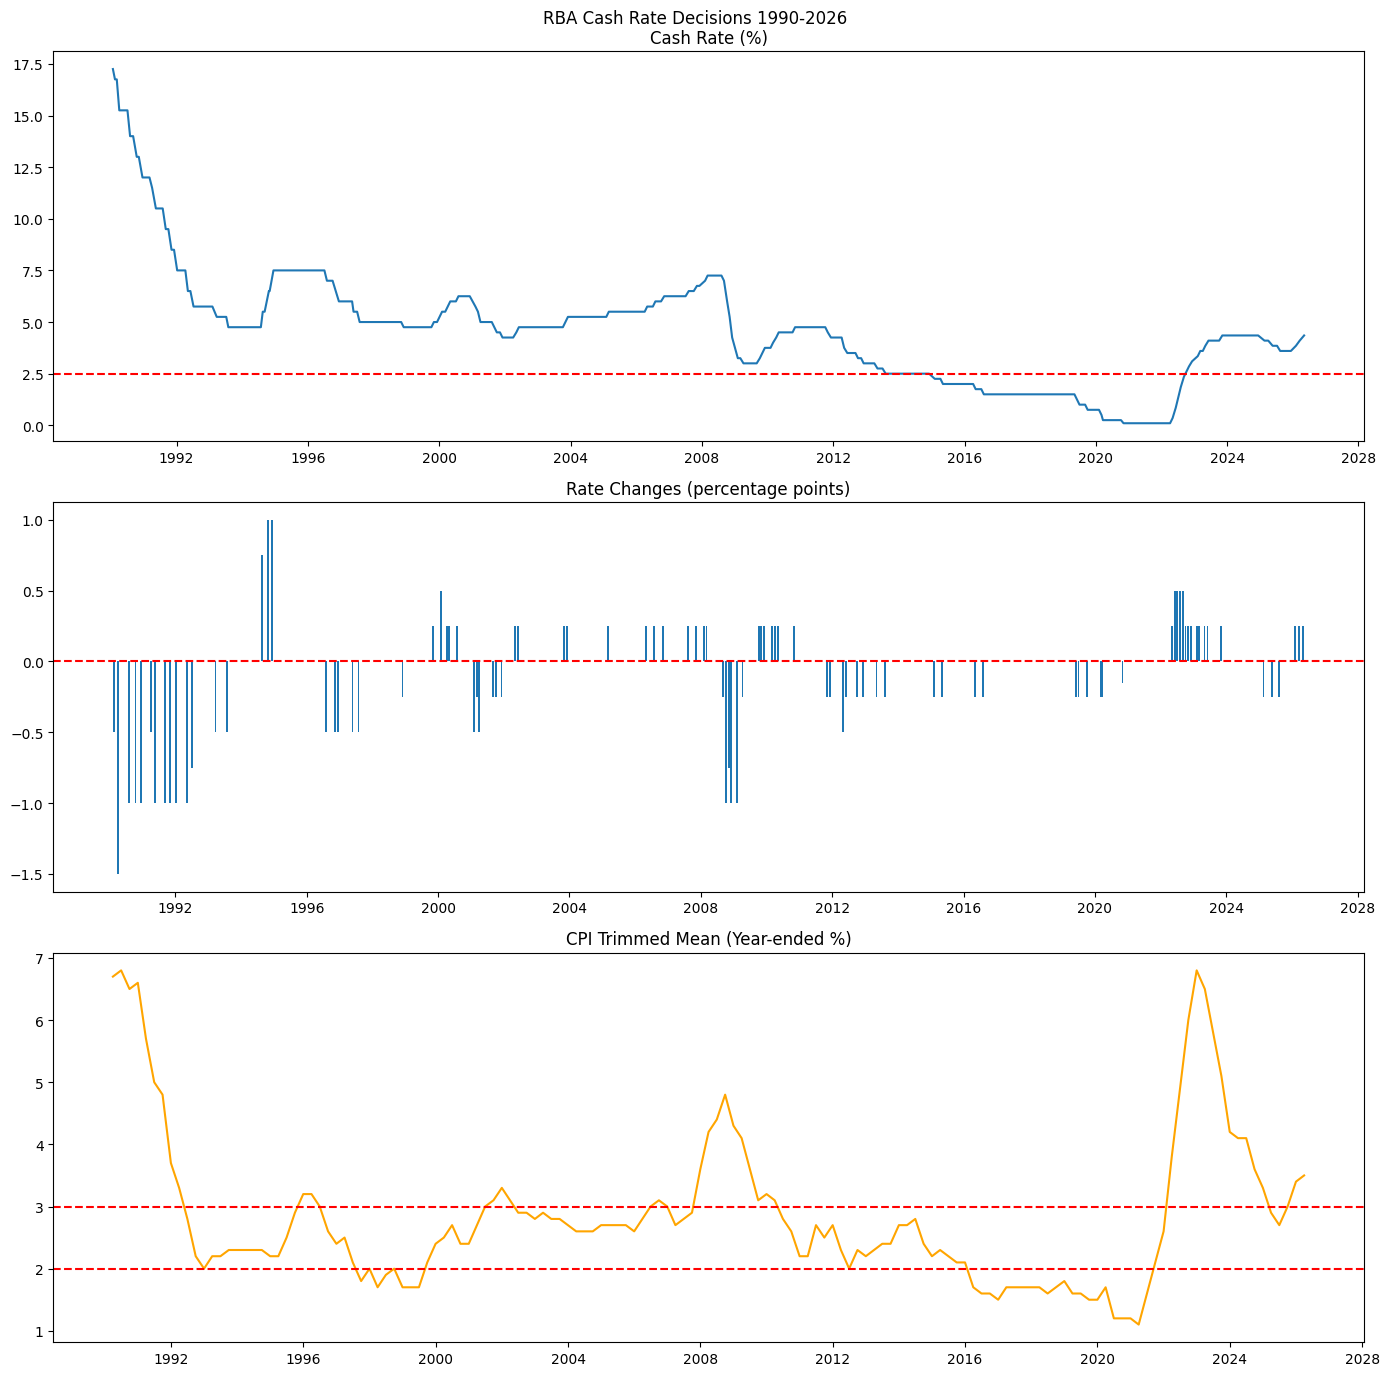

In [59]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 14))
fig.suptitle('RBA Cash Rate Decisions 1990-2026')

axes[0].plot(df_rba['date'], df_rba['cash_rate'])
axes[0].set_title('Cash Rate (%)')
axes[0].axhline(y=2.5, color='r', linestyle='--')

axes[1].bar(df_rba['date'], df_rba['change'], width=20)
axes[1].set_title('Rate Changes (percentage points)')
axes[1].axhline(y=0, color='r', linestyle='--')

df_cpi_plot = df_cpi_g1[df_cpi_g1['date'] >= '1990-01-01'].copy()
df_cpi_plot['trimmed_mean_yoy'] = pd.to_numeric(df_cpi_plot['trimmed_mean_yoy'], errors='coerce')
df_cpi_plot = df_cpi_plot.dropna()
axes[2].plot(df_cpi_plot['date'], df_cpi_plot['trimmed_mean_yoy'], color='orange')
axes[2].set_title('CPI Trimmed Mean (Year-ended %)')
axes[2].axhline(y=2, color='r', linestyle='--')
axes[2].axhline(y=3, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [61]:
for name, df in [('rba', df_rba), ('cpi', df_cpi_g1), ('unemployment', df_labour_force_h5),
                ('commodities', df_commodity_i2), ('consumption', df_gov_exp_h2),
                ('wages', df_productivity_h4), ('gdp', df_gdp_h1)]:
                print(name, df['date'].dtype, df['date'].is_monotonic_increasing)

rba datetime64[ns] True
cpi datetime64[ns] True
unemployment datetime64[ns] True
commodities datetime64[ns] True
consumption datetime64[ns] True
wages datetime64[ns] True
gdp datetime64[ns] True


In [62]:
df_merged = pd.merge_asof(df_rba, 
                          df_cpi_g1[['date', 'trimmed_mean_yoy', 'trimmed_mean_quarterly']],
                          on='date')

df_merged = pd.merge_asof(df_merged,
                         df_labour_force_h5[['date', 'unemployed_%', 'unemployed_trend']],
                         on='date')

df_merged = pd.merge_asof(df_merged,
                         df_commodity_i2[['date', 'overall_AU$', 'bulk_AU$']],
                         on='date')

df_merged = pd.merge_asof(df_merged,
                         df_gov_exp_h2[['date', 'household_consump', 'government_spending']],
                         on='date')

df_merged = pd.merge_asof(df_merged,
                         df_productivity_h4[['date', 'year_ended_wage_growth', 'year_ended_productivity_growth']],
                         on='date')

df_merged = pd.merge_asof(df_merged,
                         df_gdp_h1[['date', 'GDP_%']],
                         on='date')

print(df_merged.shape)
df_merged.head()

(399, 14)


,date,change,cash_rate,trimmed_mean_yoy,trimmed_mean_quarterly,unemployed_%,unemployed_trend,overall_AU$,bulk_AU$,household_consump,government_spending,year_ended_wage_growth,year_ended_productivity_growth,GDP_%
0,1990-01-23,NaN,17.25,6.2,1.7,5.8,6.0,31.4,23.1,4.8,NaN,NaN,-1.4,3.7
1,1990-02-15,-0.5,16.75,6.2,1.7,6.1,6.0,31.3,23.4,4.8,NaN,NaN,-1.4,3.7
2,1990-03-07,0.0,16.75,6.2,1.7,6.4,6.1,31.7,24.0,4.8,NaN,NaN,-1.4,3.7
3,1990-04-04,-1.5,15.25,6.7,1.7,6.2,6.2,32.0,24.3,3.7,NaN,NaN,0.8,3.5
4,1990-05-02,0.0,15.25,6.7,1.7,6.3,6.4,31.8,25.0,3.7,NaN,NaN,0.8,3.5


In [63]:
print(df_merged[['government_spending', 'year_ended_wage_growth']].isna().sum())  
print(df_merged[df_merged['year_ended_wage_growth'].isna()]['date'].max())


government_spending        15
year_ended_wage_growth    101
dtype: int64
1998-09-02 00:00:00


In [ ]:
#decision made to drop wage growth as there is a lot of missing data (8 years)

In [65]:
df_merged = df_merged.drop(columns=['year_ended_wage_growth'])
print(df_merged.isna().sum())

date                               0
change                             1
cash_rate                          0
trimmed_mean_yoy                   0
trimmed_mean_quarterly             0
unemployed_%                       1
unemployed_trend                   1
overall_AU$                        0
bulk_AU$                           0
household_consump                  1
government_spending               15
year_ended_productivity_growth     1
GDP_%                              1
dtype: int64


In [66]:
print(df_merged[df_merged['government_spending'].isna()]['date'])

0     1990-01-23
1     1990-02-15
2     1990-03-07
3     1990-04-04
4     1990-05-02
5     1990-06-06
6     1990-07-04
7     1990-08-02
8     1990-09-05
9     1990-10-15
10    1990-11-07
11    1990-12-18
12    1991-02-06
13    1991-03-06
398   2026-05-06
Name: date, dtype: datetime64[ns]


In [67]:
df_merged['government_spending'] = df_merged['government_spending'].ffill()

In [68]:
df_merged['government_spending'] = df_merged['government_spending'].bfill()

In [69]:
print(df_merged.isna().sum())

date                              0
change                            1
cash_rate                         0
trimmed_mean_yoy                  0
trimmed_mean_quarterly            0
unemployed_%                      1
unemployed_trend                  1
overall_AU$                       0
bulk_AU$                          0
household_consump                 1
government_spending               0
year_ended_productivity_growth    1
GDP_%                             1
dtype: int64


In [70]:
df_merged = df_merged.dropna().reset_index(drop=True)
print(df_merged.shape)

(397, 13)


In [71]:
df_merged.to_parquet('rba_merged.parquet', index=False)

In [ ]:
import seaborn as sns

pd_var = df_merged[['trimmed_mean_yoy', 'unemployed_%', 'overall_AU$', 'household_consump', 'year_ended_productivity_growth', 'GDP_%']]
cor_mat = pd_var.corr()
sns.heatmap(cor_mat)
